In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

In [14]:
fake_df.head()
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [15]:
print("Fake News Dataset Shape :", fake_df.shape)
print("True News Dataset Shape :", true_df.shape)

Fake News Dataset Shape : (23481, 4)
True News Dataset Shape : (21417, 4)


In [17]:
fake_df.info()
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [19]:
fake_df.isnull().sum()
true_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [23]:
fake_df.duplicated().sum()
true_df.duplicated().sum()

np.int64(206)

In [25]:
fake_df = fake_df.drop_duplicates()
true_df = true_df.drop_duplicates()

In [27]:
fake_df.describe(include='object')

,title,text,subject,date
count,23478,23478,23478,23478
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [28]:
fake_df.describe(include='object')

,title,text,subject,date
count,23478,23478,23478,23478
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [29]:
fake_df["label"] = 0
true_df["label"] = 1

In [34]:
df = pd.concat([fake_df, true_df], ignore_index=True)

In [35]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [33]:
df.shape

(44689, 5)

In [36]:
# Shuffle Dataset
df = df.sample(frac=1, random_state=42)

In [38]:
df.reset_index(drop=True, inplace=True)

In [40]:
df["label"].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

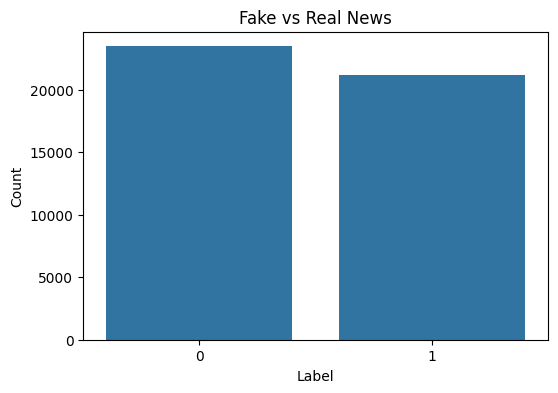

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Fake vs Real News")

plt.xlabel("Label")

plt.ylabel("Count")

plt.show()

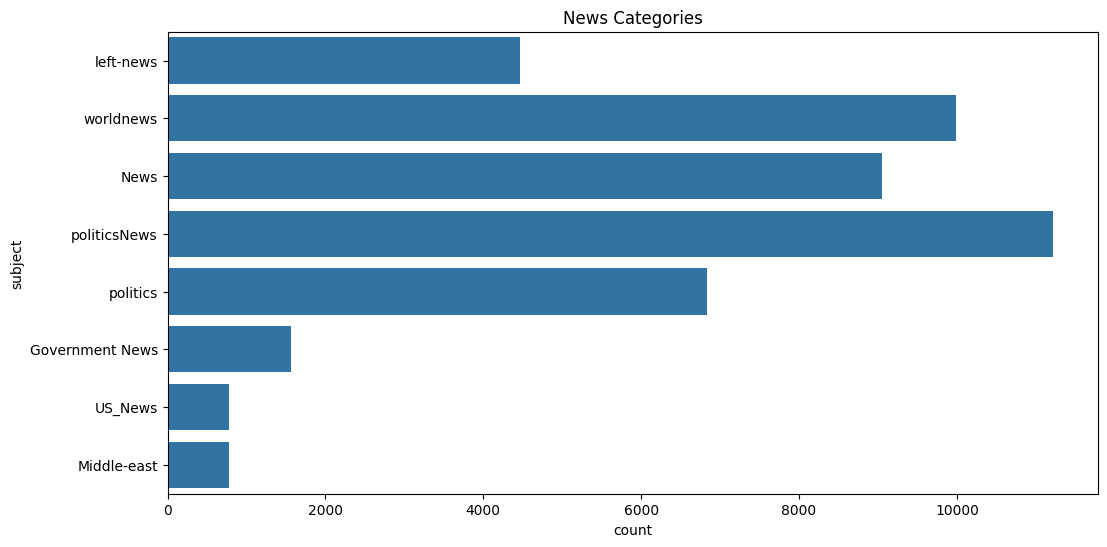

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(y="subject", data=df)

plt.title("News Categories")

plt.show()

In [43]:
df["text_length"] = df["text"].apply(len)

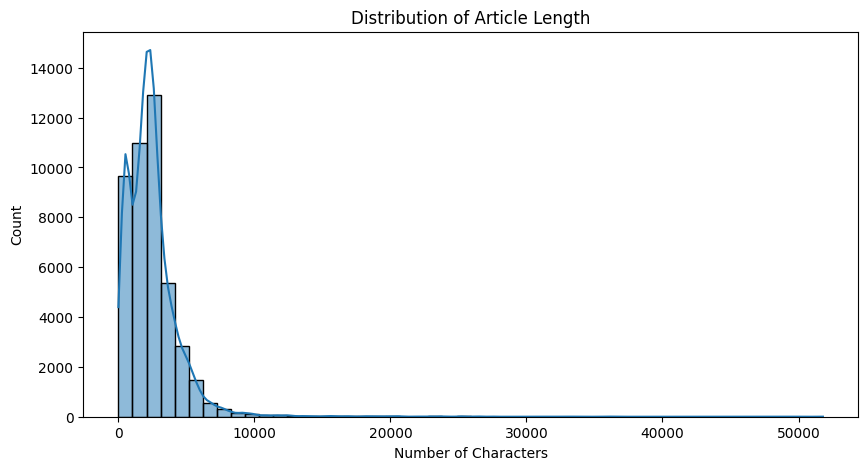

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(df["text_length"], bins=50, kde=True)

plt.title("Distribution of Article Length")

plt.xlabel("Number of Characters")

plt.show()

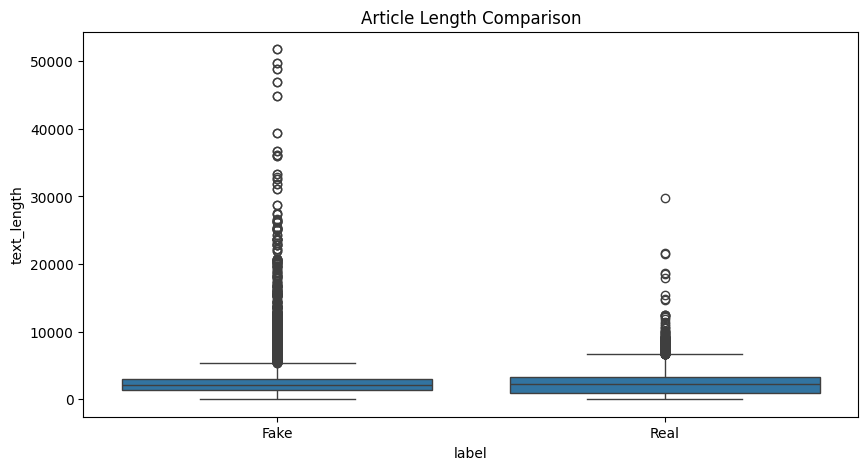

In [45]:
plt.figure(figsize=(10,5))

sns.boxplot(x="label", y="text_length", data=df)

plt.xticks([0,1],["Fake","Real"])

plt.title("Article Length Comparison")

plt.show()

In [46]:
df["subject"].value_counts()

subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

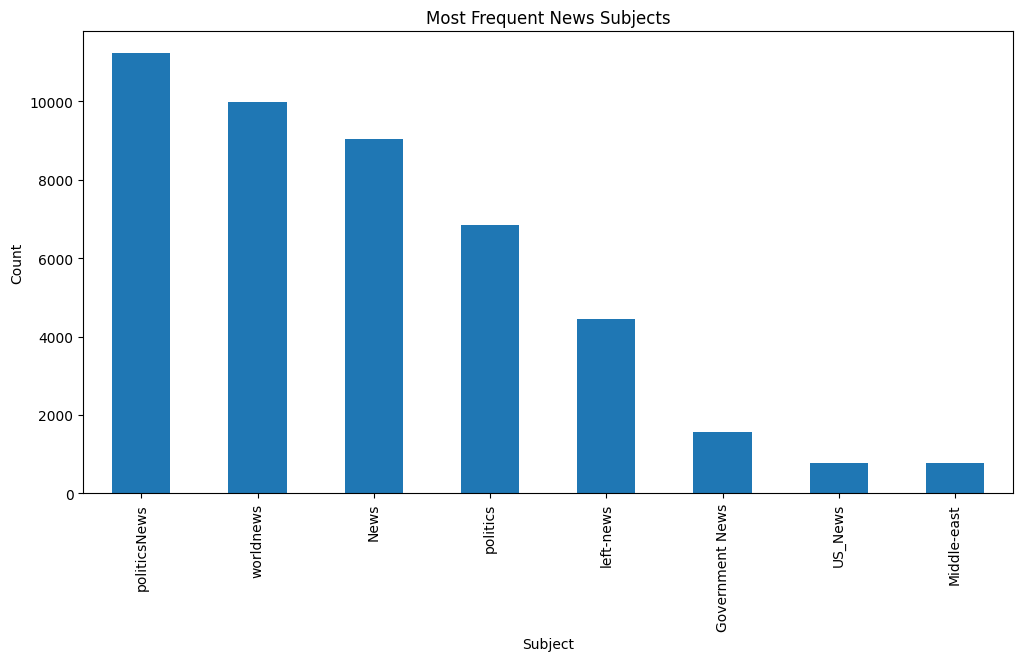

In [47]:
plt.figure(figsize=(12,6))

df["subject"].value_counts().plot(kind="bar")

plt.title("Most Frequent News Subjects")

plt.xlabel("Subject")

plt.ylabel("Count")

plt.show()

0         Sep 28, 2017
1    October 29, 2017 
2    December 6, 2017 
3          May 8, 2015
4       March 11, 2016
Name: date, dtype: object

In [52]:
df["text"][0]

'A school librarian in Cambridge, Massachusetts, rejected a shipment of books that were donated by first lady Melania Trump, according to CBS Boston.#HBFamilyReading: "Dear Mrs. Trump": @reflectlibrary says, Thanks but no thanks to the First Lady + Dr. Seuss  https://t.co/98SUPkjUN6 pic.twitter.com/3t6U6vvwPI  The Horn Book (@HornBook) September 26, 2017CBS Boston on Wednesday reported that Liz Phipps Soeiro of Cambridgeport Elementary School turned down the works Trump intended to send.The White House chose one school in all 50 states to receive a package of 10 books authored by children s literary author Dr. Seuss.The initiative was meant to promote education and childhood literacy as part of National Read A Book Day.Soeiro on Tuesday penned an editorial for the Horn Book s Family Reading blog explaining why her school did not need the donation. My students have access to a school library with over nine thousand volumes and a librarian with a graduate degree in literary science,  she

In [56]:
df["text"] = df["text"].str.lower()
df["text"][0]

'a school librarian in cambridge, massachusetts, rejected a shipment of books that were donated by first lady melania trump, according to cbs boston.#hbfamilyreading: "dear mrs. trump": @reflectlibrary says, thanks but no thanks to the first lady + dr. seuss  https://t.co/98supkjun6 pic.twitter.com/3t6u6vvwpi  the horn book (@hornbook) september 26, 2017cbs boston on wednesday reported that liz phipps soeiro of cambridgeport elementary school turned down the works trump intended to send.the white house chose one school in all 50 states to receive a package of 10 books authored by children s literary author dr. seuss.the initiative was meant to promote education and childhood literacy as part of national read a book day.soeiro on tuesday penned an editorial for the horn book s family reading blog explaining why her school did not need the donation. my students have access to a school library with over nine thousand volumes and a librarian with a graduate degree in literary science,  she

In [57]:
import re

In [58]:
df["text"] = df["text"].apply(lambda x: re.sub(r'http\S+', '', x))

In [60]:
df["text"] = df["text"].apply(lambda x: re.sub(r'<.*?>', '', x))

In [61]:
import string

In [62]:
df["text"] = df["text"].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

In [64]:
df["text"] = df["text"].apply(lambda x: re.sub(r'\d+', '', x))

In [65]:
df["text"] = df["text"].apply(lambda x: " ".join(x.split()))

In [66]:
from nltk.corpus import stopwords

import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [67]:
df["text"] = df["text"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [73]:
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [74]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [75]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

In [76]:
tokenizer.fit_on_texts(df["text"])

In [77]:
tokenizer.word_index

{'<OOV>': 1,
 'said': 2,
 'trump': 3,
 'us': 4,
 'would': 5,
 'president': 6,
 'people': 7,
 'one': 8,
 'also': 9,
 'state': 10,
 'new': 11,
 'reuters': 12,
 'donald': 13,
 'house': 14,
 'government': 15,
 'clinton': 16,
 'states': 17,
 'obama': 18,
 'republican': 19,
 'could': 20,
 'united': 21,
 'told': 22,
 'white': 23,
 'like': 24,
 'campaign': 25,
 'last': 26,
 'news': 27,
 'two': 28,
 'time': 29,
 'election': 30,
 'party': 31,
 'first': 32,
 'year': 33,
 'former': 34,
 'even': 35,
 'washington': 36,
 'country': 37,
 'many': 38,
 'hillary': 39,
 'years': 40,
 'security': 41,
 'media': 42,
 'may': 43,
 'national': 44,
 'political': 45,
 'say': 46,
 'made': 47,
 'get': 48,
 'police': 49,
 'law': 50,
 'make': 51,
 'since': 52,
 'american': 53,
 'percent': 54,
 'going': 55,
 'court': 56,
 'presidential': 57,
 'republicans': 58,
 'back': 59,
 'democratic': 60,
 'support': 61,
 'bill': 62,
 'administration': 63,
 'including': 64,
 'week': 65,
 'according': 66,
 'senate': 67,
 'know': 68

In [78]:
print(len(tokenizer.word_index))

225994


In [79]:
sequences = tokenizer.texts_to_sequences(df["text"])

In [80]:
print(df["text"][0])
print(sequences[0])

school librarian cambridge massachusetts rejected shipment books donated first lady melania trump according cbs bostonhbfamilyreading dear mrs trump reflectlibrary says thanks thanks first lady dr seuss pictwittercomtuvvwpi horn book hornbook september cbs boston wednesday reported liz phipps soeiro cambridgeport elementary school turned works trump intended sendthe white house chose one school states receive package books authored children literary author dr seussthe initiative meant promote education childhood literacy part national read book daysoeiro tuesday penned editorial horn book family reading blog explaining school need donation students access school library nine thousand volumes librarian graduate degree literary science wrote multiple studies show schools professionally staffed libraries improve student performance soeiro addedtrump package reportedly included seuss classics green eggs ham cat hat one fish two fish red fish blue fish soeiro criticized seuss author represe

In [81]:
sequence_lengths = [len(seq) for seq in sequences]

In [82]:
import numpy as np

print("Minimum:", min(sequence_lengths))
print("Maximum:", max(sequence_lengths))
print("Average:", np.mean(sequence_lengths))
print("90th:", np.percentile(sequence_lengths,90))
print("95th:", np.percentile(sequence_lengths,95))

Minimum: 0
Maximum: 4841
Average: 229.33010360491397
90th: 426.0
95th: 524.0


In [83]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [86]:
X = pad_sequences(
    sequences,
    maxlen=524,
    padding="post",
    truncating="post"
)

In [87]:
print(X.shape)

(44689, 524)


In [88]:
y = df["label"]

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(35751, 524)
(8938, 524)
(35751,)
(8938,)


In [91]:
print(y_train.value_counts())

print(y_test.value_counts())

label
0    18782
1    16969
Name: count, dtype: int64
label
0    4696
1    4242
Name: count, dtype: int64


In [92]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

In [93]:
model = Sequential()

In [94]:
model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=524
    )
)

C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [95]:
model.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu"
    )
)

In [96]:
model.add(MaxPooling1D(pool_size=2))

In [97]:
model.add(
    Dropout(0.5)
)

In [98]:
model.add(
    GlobalMaxPooling1D()
)

In [99]:
model.add(
    Dense(
        64,
        activation="relu"
    )
)

In [100]:
model.add(
    Dropout(0.5)
)

In [101]:
model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

In [102]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [103]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 131s 112ms/step - accuracy: 0.9735 - loss: 0.0621 - val_accuracy: 0.9979 - val_loss: 0.0087
Epoch 2/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 115s 103ms/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9974 - val_loss: 0.0094
Epoch 3/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 121s 108ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9979 - val_loss: 0.0069
Epoch 4/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 118s 106ms/step - accuracy: 0.9998 - loss: 9.1608e-04 - val_accuracy: 0.9970 - val_loss: 0.0169
Epoch 5/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 120s 107ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 0.9977 - val_loss: 0.0126
Epoch 6/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 120s 108ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9984 - val_loss: 0.0089
Epoch 7/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 463s 414ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9974 - val_loss: 0.0153
Epoch 8/10
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 145s 111ms/step 

In [104]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

280/280 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9973 - loss: 0.0257
Test Loss: 0.025692619383335114
Test Accuracy: 0.9973148107528687


In [105]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step


In [106]:
# Convert probabilities to class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

In [107]:
y_pred = y_pred.flatten()

In [108]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [109]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4674   22]
 [   2 4240]]


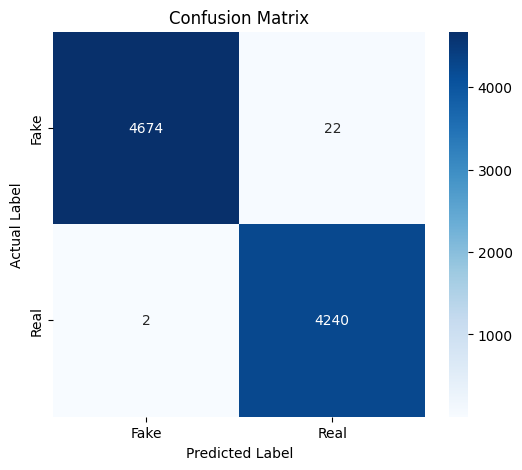

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [111]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       0.99      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



In [116]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9973148355336764
Precision : 0.994838104176443
Recall : 0.9995285242809995
F1 Score : 0.9971777986829727


In [117]:
model.save("fake_news_cnn_model.keras")

In [118]:
from tensorflow.keras.models import load_model

model = load_model("fake_news_cnn_model.keras")

In [119]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [120]:
import pickle

with open("tokenizer.pkl", "rb") as file:
    tokenizer = pickle.load(file)